# Perspectives and visualizations

## Europe's Energy Transition: Urgency Meets Reality

Europe's energy landscape is undergoing a rapid, necessary transformation. The dual challenges of climate urgency and economic reality frame this important shift. Fully decarbonizing the continent's energy system demands immense investment, estimated at trillions of euros (European Commission, 2020), even as renewable energy technologies become increasingly cost-competitive (IRENA, 2021). Our analysis delves into how Europe is navigating these complexities, powered by insights from recent data.

### The Economic and Social Feasibility Challenge

One critical aspect is understanding if European countries can economically and socially handle this profound change. The sheer scale of historical reliance on fossil fuels is evident in the **Cumulative CO2 Emissions from Fossil Fuels in Selected European Countries (since 1950)** stacked area chart, where nations like the UK and Germany show decades of significant carbon output, followed by France, Italy, Poland, and Spain. This legacy means a substantial transition burden. This multivariate stacked are chart shows how the emissions from different European countries changed through the years.

In [24]:
import plotly.io as pio
pio.renderers.default = "notebook_connected"

In [15]:
import pandas as pd
import plotly.express as px

# Load the dataset
owid_co2_data_df = pd.read_csv('owid-co2-data.csv')

# Define a list of European countries
european_countries = [
    'Austria', 'Belgium', 'Bulgaria', 'Croatia', 'Cyprus', 'Czechia', 'Denmark',
    'Estonia', 'Finland', 'France', 'Germany', 'Greece', 'Hungary', 'Ireland',
    'Italy', 'Latvia', 'Lithuania', 'Luxembourg', 'Malta', 'Netherlands',
    'Poland', 'Portugal', 'Romania', 'Slovakia', 'Slovenia', 'Spain', 'Sweden',
    'United Kingdom', 'Norway', 'Switzerland', 'Iceland'
]

# Select a few key countries for this cumulative view (to avoid clutter)
selected_countries_cumulative = ['Germany', 'United Kingdom', 'France', 'Italy', 'Spain', 'Poland']

# Filter for selected European countries and years from 1950 onwards
df_cumulative = owid_co2_data_df[
    (owid_co2_data_df['country'].isin(selected_countries_cumulative)) &
    (owid_co2_data_df['year'] >= 1950)
].copy()

# Select the 'cumulative_co2' column and ensure it's numeric
df_cumulative_filtered = df_cumulative[['country', 'year', 'cumulative_co2']].dropna()
df_cumulative_filtered['cumulative_co2'] = pd.to_numeric(df_cumulative_filtered['cumulative_co2'])

# 追加: contrastrijke kleuren
contrast_colors = [
    '#FFD700',  # goudgeel
    '#FF7F0E',  # oranje
    '#2CA02C',  # groen
    '#D62728',  # rood
    '#9467BD',  # paars
    '#17BECF'   # cyaan
]

# Create the stacked area chart for cumulative CO2 emissions
fig = px.area(
    df_cumulative_filtered,
    x="year",
    y="cumulative_co2",
    color="country",
    line_group="country",
    hover_name="country",
    title="Cumulative CO2 Emissions from Fossil Fuels in Selected European Countries (since 1950)",
    labels={
        "year": "Year",
        "cumulative_co2": "Cumulative CO2 Emissions (million tonnes)"
    },
    color_discrete_sequence=contrast_colors  # 追加: custom palette
)

fig.update_layout(
    xaxis_title="Year",
    yaxis_title="Cumulative CO2 Emissions (million tonnes)",
    hovermode="x unified",
    paper_bgcolor='#004084',
    plot_bgcolor='#004084',
    title_font_color='white',
    legend_font_color='white'
)

fig.update_xaxes(
    showgrid=True,
    gridcolor='rgba(255,255,255,0.2)',
    zerolinecolor='white',
    color='white'
)
fig.update_yaxes(
    showgrid=False,
    color='white'
)

fig.show()



This graph visually demonstrating the massive scale of Europe's historical fossil fuel reliance. It clearly shows the enormous cumulative CO2 emissions, reaching hundreds of thousands of million tonnes, proving the "sheer scale" mentioned. Crucially, the graph ranks the countries just as described: the UK and Germany have the largest emissions over decades, followed by France, Italy, Poland, and Spain. This visual evidence of unequal historical responsibility makes concrete why countries like the UK and Germany face a bigger "substantial transition burden" – they have the largest legacy of past pollution to overcome.

Financially, the journey is demanding. Our **Energy Costs per European Country (Renewable vs Fossil)** horizontal bar chart highlights the fluctuating financial commitments over time, with leading economies like France, Germany, the UK, Italy, and Spain seeing costs exceed €20 billion in 2015, peaking above €100 billion in 2022, before moderating to under €20 billion in 2025. The peak in 2022 can possibly be attributed to the increased energy demand due to the pandemic and growing tension between Russia and Ukraine (Cevik et al., 2022).

In [12]:
import pandas as pd
import plotly.express as px

# 1) Data laden en bewerken
price = pd.read_csv('european_wholesale_electricity_price_data_monthly.csv', parse_dates=['Date'])
gen = pd.read_csv('data2.csv', skiprows=7,
                  names=['Country','Time','Balance','Product','Value','Unit'],
                  low_memory=False)

gen = gen[gen['Balance']=='Net Electricity Production'].copy()
gen['Time'] = pd.to_datetime(gen['Time'], format='%B %Y')
gen['Value'] = pd.to_numeric(gen['Value'], errors='coerce')

total_prod = gen[gen['Product']=='Electricity'][['Country','Time','Value']].rename(columns={'Value':'Total_GWh'})
renew_prod = gen[gen['Product']=='Total Renewables (Hydro, Geo, Solar, Wind, Other)'][['Country','Time','Value']].rename(columns={'Value':'Renewable_GWh'})

df = total_prod.merge(renew_prod, on=['Country','Time'], how='inner')
df = df.merge(
    price[['Country','Date','Price (EUR/MWhe)']].rename(columns={'Date':'Time','Price (EUR/MWhe)':'Price'}),
    on=['Country','Time'], how='inner'
)

df['Total_MWh']     = df['Total_GWh'] * 1000
df['Renewable_MWh'] = df['Renewable_GWh'] * 1000
df['Cost_Total']    = df['Price'] * df['Total_MWh']
df['Cost_Renewable']= df['Price'] * df['Renewable_MWh']
df['Cost_Fossil']   = df['Cost_Total'] - df['Cost_Renewable']

df['Year'] = df['Time'].dt.year
agg = df.groupby(['Year','Country'])[['Cost_Renewable','Cost_Fossil','Cost_Total']].sum() / 1e9
agg = agg.reset_index()

# 2) Fixed vertical order gebaseerd op laatste jaar
last_year   = agg['Year'].max()
fixed_order = (
    agg[agg['Year']==last_year]
    .sort_values('Cost_Total', ascending=False)['Country']
    .tolist()
)

# 3) Maak animated bar chart met fixed order
fig = px.bar(
    agg,
    x=['Cost_Renewable','Cost_Fossil'],
    y='Country',
    orientation='h',
    animation_frame='Year',
    category_orders={'Year': sorted(agg['Year'].unique()), 'Country': fixed_order},
    labels={'value':'Cost (billion EUR)','variable':'Type','Country':'Country','Year':'Year'},
    title='Energy Costs per European Country (Renewable vs Fossil)'
)

fig.update_layout(
    barmode='stack',
    height=800,
    margin=dict(l=50, r=20, t=50, b=50),
    transition={'duration':1000,'easing':'cubic-in-out'}
)

# 4) Smooth slider
if fig.layout.sliders:
    fig.layout.sliders[0].transition = {'duration':1000,'easing':'cubic-in-out'}

# 5) Fixed reversed y-axis
fig.update_yaxes(autorange='reversed', categoryorder='array', categoryarray=fixed_order)

# 6) Definieer per-jaar x-as limieten
#    2015–2020 → max 30, 2021–2023 → max 120, 2025 → max 30
year_max = {
    **{yr: 30  for yr in range(2015, 2021)},
    **{yr: 130 for yr in (2021,2022,2023)},
    2025: 30
}

# 7) Pas per-frame x-as en forceer redraw
for frame in fig.frames:
    yr = int(frame.name)
    if yr in year_max:
        frame.layout.xaxis.range     = [0, year_max[yr]]
        frame.layout.xaxis.autorange = False
    else:
        frame.layout.xaxis.autorange = True
    frame.layout.yaxis = {'autorange':'reversed'}

updater = fig.layout.updatemenus[0].buttons[0].args[1]
updater['frame']['redraw']      = True
updater['transition']['duration']= 1000
updater['transition']['easing']  = 'cubic-in-out'
updater['frame']['duration']     = 2000
updater['frame']['easing']       = 'cubic-in-out'

# 8) Optioneel: forceer basislayout op langst geldende max 
#    (zorgt dat de as nooit naar links ‘springt’ na einde animatie)
global_max = max(year_max.values())
fig.update_xaxes(range=[0, global_max], autorange=False, rangemode='tozero')

fig.update_layout(
    paper_bgcolor='#004084',   # achtergrond rondom het volledige figuur
    plot_bgcolor='#004084'     # achtergrond achter de bars zelf
)

# Als je wilt dat de assen en gridlijnen beter contrasteren kun je ze ook wit maken:
fig.update_xaxes(showgrid=True, gridcolor='rgba(255,255,255,0.2)', zerolinecolor='white', color='white')
fig.update_yaxes(showgrid=False, color='white')

# En desgewenst ook de titel- en legend-teksten:
fig.update_layout(
    title_font_color='white',
    legend_font_color='white'
)
if fig.layout.sliders:
    s = fig.layout.sliders[0]
    s.bgcolor      = '#004084'           # slider-track
    s.bordercolor  = 'white'
    s.borderwidth  = 1
    s.font.color   = 'white'             # tick labels (jaartallen)
    s.currentvalue.font.color = 'white'  # actuele waarde

# play/pause buttons
if fig.layout.updatemenus:
    u = fig.layout.updatemenus[0]
    u.bgcolor     = '#004084'
    u.bordercolor = 'white'
    u.borderwidth = 1
    u.font.color  = 'white'

# 9) Render
fig.show()


This volatility in investment is further reflected in the **Wholesale Electricity Price Trends in Select European Countries** line chart, which shows prices largely below €100/MWh until a dramatic surge to over €500/MWh in mid-2022 for some countries, before returning to more moderate levels by 2023. Such price swings underscore the inherent market risks and the need for robust financial strategies during the transition. This chart shows the same peak in 2022 the previous chart shows. This can also be attributed to the increased energy demand due to the pandemic and growing tension between Russia and Ukraine (Cevik et al., 2022).

In [33]:
import pandas as pd
import plotly.express as px

# 1) Data inladen en filteren
df = pd.read_csv('european_wholesale_electricity_price_data_monthly.csv')
df['Date'] = pd.to_datetime(df['Date'])
df = df[df['Date'].dt.year >= 2015]
countries = ['Germany', 'France', 'United Kingdom', 'Spain', 'Italy', 'Netherlands']
df = df[df['Country'].isin(countries)]

# 2) Zeer contrastrijke kleuren (geen blauwtint)
contrast_colors = ['#FF0000','#FFA500','#FFFF00','#00FF00','#00FFFF','#FF00FF']

# 3) Maak interactieve line chart met extra grote afmetingen
fig = px.line(
    df,
    x='Date',
    y='Price (EUR/MWhe)',
    color='Country',
    title='Wholesale Electricity Price Trends in Selected European Countries',
    color_discrete_sequence=contrast_colors,
    labels={'Price (EUR/MWhe)':'Price (EUR/MWhe)', 'Date':'Date'},
    width=1600,     # <<< breder
    height=900      # <<< hoger
)

# 4) Achtergrond en styling
fig.update_layout(
    paper_bgcolor='#004084',
    plot_bgcolor='#004084',
    font_color='white',
    title_font_size=24,
    legend_title_font_color='white'
)

# 5) Assen en grid in wit
fig.update_xaxes(
    showgrid=True,
    gridcolor='rgba(255,255,255,0.3)',
    zerolinecolor='white',
    tickfont_color='white',
    title_font_color='white'
)
fig.update_yaxes(
    showgrid=True,
    gridcolor='rgba(255,255,255,0.3)',
    zerolinecolor='white',
    tickfont_color='white',
    title_font_color='white'
)

fig.show()






**Note:** See prices jump from stable (<€100) to extreme (>€500) in 2022, proving the volatility described above and the need for strong financial planning during the energy transition.

The ability to invest varies significantly across the continent. The **Correlation between GDP and CO2 emissions for EU Countries (2022)** scatterplot with a trendline clearly illustrates that wealthier countries such as Germany, Spain, Italy, and France tend to have higher overall CO2 emissions, reflecting a historical link between economic development and carbon intensity(Apeti et al., 2025). Conversely, countries with lower GDPs, like Austria, Greece, Slovakia, and Estonia, generally show lower emissions.

In [40]:
import pandas as pd
import numpy as np
import plotly.express as px

# 1) Data inladen en filteren
url = 'https://raw.githubusercontent.com/owid/co2-data/master/owid-co2-data.csv'
df = pd.read_csv(url)
df = df[df['year'] == 2022]
eu_countries = [
    'Austria', 'Belgium', 'Bulgaria', 'Croatia', 'Cyprus', 'Czechia',
    'Denmark', 'Estonia', 'Finland', 'France', 'Germany', 'Greece',
    'Hungary', 'Ireland', 'Italy', 'Latvia', 'Lithuania', 'Luxembourg',
    'Malta', 'Netherlands', 'Poland', 'Portugal', 'Romania',
    'Slovakia', 'Slovenia', 'Spain', 'Sweden'
]
df = df[df['country'].isin(eu_countries)].dropna(subset=['gdp', 'co2'])

# 2) Log-transformatie
df['log_gdp'] = np.log10(df['gdp'])
df['log_co2'] = np.log10(df['co2'])

# 3) Maak interactieve scatter met regressielijn
fig = px.scatter(
    df,
    x='log_gdp',
    y='log_co2',
    text='country',
    trendline='ols',
    trendline_color_override='white',
    title='Correlation between GDP and CO₂ emissions for EU countries (2022) – log-scale',
    labels={'log_gdp':'Log10 GDP (dollars)', 'log_co2':'Log10 CO₂ (ton)'},
    width=1600,
    height=1000
)

# 4) Marker-punten wít maken
fig.update_traces(
    marker=dict(color='white', size=12, line=dict(color='white', width=1)),
    selector=lambda trace: 'markers' in trace.mode
)

# 5) Landnamen in geel en nét boven de stip zetten
fig.update_traces(
    textfont=dict(color='#FFD700', size=16),
    textposition='top center',
    selector=lambda trace: 'text' in trace.mode
)

# 6) Styling: donkerblauwe ondergrond en witte assen/grid/tekst
fig.update_layout(
    paper_bgcolor='#004084',
    plot_bgcolor='#004084',
    font_color='white',
    title_font_size=24
)

fig.update_xaxes(
    showgrid=True,
    gridcolor='rgba(255,255,255,0.3)',
    zerolinecolor='white',
    tickfont_color='white',
    title_font_color='white'
)
fig.update_yaxes(
    showgrid=True,
    gridcolor='rgba(255,255,255,0.3)',
    zerolinecolor='white',
    tickfont_color='white',
    title_font_color='white'
)

fig.show()






 This graph highlights the complex challenge of decoupling economic growth from emissions while also suggesting that wealthier nations may be better equipped to absorb the significant costs of decarbonization.

Despite the financial weight, many European nations are actively pushing forward. The **Renewable electricity share in European Production (March 2025)** chloropleth map showcases considerable progress in countries like Iceland and Norway, nearing 100% renewable energy penetration. Countries such as Croatia, Portugal, and Luxembourg also demonstrate strong renewable shares, around 80%. However, major economies like France, Italy, the Netherlands, and Germany remain under 50%, indicating that substantial work is still required to integrate renewables fully. These disparities reflect a combination of natural resource availability, existing infrastructure, policy environments, and financial capacity.

In [29]:
import pandas as pd
import plotly.express as px

# Load the datasets
owid_co2_data_df = pd.read_csv('owid-co2-data.csv') # To get ISO codes
data2_df = pd.read_csv('data2.csv', skiprows=8)

# Define a list of European countries
european_countries = [
    'Austria', 'Belgium', 'Bulgaria', 'Croatia', 'Cyprus', 'Czechia', 'Denmark',
    'Estonia', 'Finland', 'France', 'Germany', 'Greece', 'Hungary', 'Ireland',
    'Italy', 'Latvia', 'Lithuania', 'Luxembourg', 'Malta', 'Netherlands',
    'Poland', 'Portugal', 'Romania', 'Slovakia', 'Slovenia', 'Spain', 'Sweden',
    'United Kingdom', 'Norway', 'Switzerland', 'Iceland'
]

# --- Process data2_df for renewable share ---
df_electricity_prod = data2_df[
    (data2_df['Balance'] == 'Net Electricity Production') &
    (data2_df['Unit'] == 'GWh') &
    (data2_df['Country'].isin(european_countries))
].copy()

# Convert 'Time' to datetime objects
df_electricity_prod['Date_Parsed'] = pd.to_datetime(df_electricity_prod['Time'], format='%B %Y', errors='coerce')
df_electricity_prod.dropna(subset=['Date_Parsed'], inplace=True)

# Get the latest overall date in this filtered dataset
latest_date_prod = df_electricity_prod['Date_Parsed'].max()
df_latest_prod_data = df_electricity_prod[df_electricity_prod['Date_Parsed'] == latest_date_prod].copy()

# Identify renewable and total electricity products
renewable_products = ['Hydro', 'Solar', 'Wind', 'Biofuels', 'Geothermal', 'Other renewables']
total_products = ['Electricity', 'Total Combustible Fuels'] # 'Electricity' should be total net, 'Total Combustible Fuels' for fossil

# Calculate total renewable production per country
df_renewables_agg = df_latest_prod_data[df_latest_prod_data['Product'].isin(renewable_products)].groupby('Country')['Value'].sum().reset_index()
df_renewables_agg.rename(columns={'Value': 'Renewable_Production_GWh'}, inplace=True)

# Calculate total electricity production (or a proxy for it)
# Assuming 'Electricity' product represents total net electricity production in data2_df
df_total_electricity_agg = df_latest_prod_data[df_latest_prod_data['Product'] == 'Electricity'].groupby('Country')['Value'].sum().reset_index()
df_total_electricity_agg.rename(columns={'Value': 'Total_Electricity_Production_GWh'}, inplace=True)

# Merge to calculate share
df_merged_prod = pd.merge(df_renewables_agg, df_total_electricity_agg, on='Country', how='inner')
df_merged_prod['Renewable_Share (%)'] = (df_merged_prod['Renewable_Production_GWh'] / df_merged_prod['Total_Electricity_Production_GWh']) * 100

# --- Merge with owid-co2-data_df to get ISO codes ---
# Create a mapping from country name to ISO code from owid_co2_data_df
country_to_iso = owid_co2_data_df[['country', 'iso_code']].dropna().drop_duplicates(subset=['country'])
df_merged_prod_with_iso = pd.merge(df_merged_prod, country_to_iso, left_on='Country', right_on='country', how='left')
df_merged_prod_with_iso.drop(columns='country', inplace=True) # Drop redundant country column

# Drop rows if ISO code is missing
df_merged_prod_with_iso.dropna(subset=['iso_code', 'Renewable_Share (%)'], inplace=True)

# Create the choropleth map
fig = px.choropleth(df_merged_prod_with_iso,
                    locations="iso_code",
                    color="Renewable_Share (%)", # Data to be colored
                    hover_name="Country",
                    hover_data={"Renewable_Share (%)": ":.2f", "Renewable_Production_GWh": ":.0f", "Total_Electricity_Production_GWh": ":.0f"},
                    color_continuous_scale=px.colors.sequential.Greens, # Green scale for renewable share
                    projection="natural earth",
                    title=f"Renewable Electricity Share in European Production ({latest_date_prod.strftime('%B %Y')})",
                    labels={'Renewable_Share (%)': 'Renewable Electricity Share (%)'})

# Focus the map on Europe
fig.update_geos(
    scope='europe',
    lataxis_range=[30, 75],
    lonaxis_range=[-25, 45],
    showcountries=True, countrycolor="Black"
)

fig.update_layout(height=600)

# Show the plot
fig.show()


The immediate economic landscape is also shaped by electricity prices. The **Wholesale Electricity Price in Europe (June 2025)** chloropleth map shows a striking range, with prices lowest in regions like France, Finland, and Sweden (under €30/MWh), likely due to their high nuclear or hydro capacity. In contrast, countries like Italy, Ireland, and Poland face significantly higher prices (above €80/MWh, with Italy nearing €110/MWh). These price variations can impact the competitiveness of businesses, household energy bills, and ultimately, the social acceptance and pace of the energy transition.


In [30]:
import pandas as pd
import plotly.express as px

# Load the datasets
european_electricity_prices_df = pd.read_csv('european_wholesale_electricity_price_data_monthly.csv')
owid_co2_data_df = pd.read_csv('owid-co2-data.csv') # Used to get ISO codes

# Define a list of European countries
european_countries = [
    'Austria', 'Belgium', 'Bulgaria', 'Croatia', 'Cyprus', 'Czechia', 'Denmark',
    'Estonia', 'Finland', 'France', 'Germany', 'Greece', 'Hungary', 'Ireland',
    'Italy', 'Latvia', 'Lithuania', 'Luxembourg', 'Malta', 'Netherlands',
    'Poland', 'Portugal', 'Romania', 'Slovakia', 'Slovenia', 'Spain', 'Sweden',
    'United Kingdom', 'Norway', 'Switzerland', 'Iceland'
]

# Convert 'Date' to datetime objects
european_electricity_prices_df['Date'] = pd.to_datetime(european_electricity_prices_df['Date'])

# Filter for European countries
df_prices_europe = european_electricity_prices_df[european_electricity_prices_df['Country'].isin(european_countries)].copy()

# Find the latest date available in the dataset
latest_date_price = df_prices_europe['Date'].max()

# Filter for the latest month's data for each country
df_latest_prices = df_prices_europe[df_prices_europe['Date'] == latest_date_price].copy()

# --- Merge with owid-co2-data_df to get ISO codes ---
# Create a mapping from country name to ISO code from owid_co2_data_df
country_to_iso = owid_co2_data_df[['country', 'iso_code']].dropna().drop_duplicates(subset=['country'])

# Merge the latest prices data with ISO codes
# Use a common column name 'Country' for merging, or map 'ISO3 Code' from the price data if it's consistent
# The `european_electricity_prices_df` has 'Country' and 'ISO3 Code', let's use 'ISO3 Code' directly if it's reliable for Plotly
# However, Plotly typically uses 'iso_alpha' which is ISO A3 code. 'ISO3 Code' looks like it.
df_latest_prices.rename(columns={'ISO3 Code': 'iso_alpha'}, inplace=True)
df_latest_prices.dropna(subset=['iso_alpha', 'Price (EUR/MWhe)'], inplace=True)

# Create the choropleth map
fig = px.choropleth(df_latest_prices,
                    locations="iso_alpha", # Use the renamed ISO3 Code column
                    color="Price (EUR/MWhe)", # Data to be colored
                    hover_name="Country",
                    hover_data={"Price (EUR/MWhe)": ":.2f", "Date": "|%B %Y"}, # Format price and date
                    color_continuous_scale=px.colors.sequential.Plasma, # A good color scale for prices
                    projection="natural earth",
                    title=f"Wholesale Electricity Price in Europe ({latest_date_price.strftime('%B %Y')})",
                    labels={'Price (EUR/MWhe)': 'Price (EUR/MWhe)'})

# Focus the map on Europe
fig.update_geos(
    scope='europe',
    lataxis_range=[30, 75],
    lonaxis_range=[-25, 45],
    showcountries=True, countrycolor="Black"
)

fig.update_layout(height=600)

# Show the plot
fig.show()


### The Climate Urgency Imperative

Beyond economic considerations, the climate crisis itself demands an accelerated energy transition. The urgency is underscored by Europe's current carbon footprint. The **Total CO2 emissions in Europe (2023 data)** chloropleth map illustrates that Germany, France, Poland, and the United Kingdom are still among the highest emitters, with Germany alone approaching 600 million tonnes. These current emission levels contribute directly to global warming and its pervasive impacts.

In [8]:
import pandas as pd
import plotly.express as px

# Load the dataset
owid_co2_data_df = pd.read_csv('owid-co2-data.csv')

# Define a list of European countries
european_countries = [
    'Austria', 'Belgium', 'Bulgaria', 'Croatia', 'Cyprus', 'Czechia', 'Denmark',
    'Estonia', 'Finland', 'France', 'Germany', 'Greece', 'Hungary', 'Ireland',
    'Italy', 'Latvia', 'Lithuania', 'Luxembourg', 'Malta', 'Netherlands',
    'Poland', 'Portugal', 'Romania', 'Slovakia', 'Slovenia', 'Spain', 'Sweden',
    'United Kingdom', 'Norway', 'Switzerland', 'Iceland'
]

# Filter for European countries and select relevant columns
df_europe_co2 = owid_co2_data_df[owid_co2_data_df['country'].isin(european_countries)].copy()

# Find the latest year with CO2 data for each country
latest_year_co2 = df_europe_co2.dropna(subset=['co2']).groupby('country')['year'].max().reset_index()
df_latest_co2_data = pd.merge(df_europe_co2, latest_year_co2, on=['country', 'year'])

# Ensure 'iso_code' is available for plotting (Plotly needs ISO codes for countries)
df_latest_co2_data.dropna(subset=['iso_code', 'co2'], inplace=True)

# Create the choropleth map
fig = px.choropleth(df_latest_co2_data,
                    locations="iso_code",
                    color="co2", # Data to be colored
                    hover_name="country",
                    hover_data={"co2": ":.2f", "year": True}, # Show CO2 formatted and year
                    color_continuous_scale=px.colors.sequential.Plasma, # Choose a color scale
                    projection="natural earth", # A good projection for global/continental maps
                    title=f"Total CO2 Emissions in Europe ({df_latest_co2_data['year'].max()} Data)",
                    labels={'co2': 'Total CO2 Emissions (million tonnes)'})

# Focus the map on Europe (adjusting the scope and center)
fig.update_geos(
    scope='europe',
    lataxis_range=[30, 75], # Latitude range for Europe
    lonaxis_range=[-25, 45], # Longitude range for Europe
    showcountries=True, countrycolor="Black"
)

fig.update_layout(height=600) # Adjust height for better visibility

# Show the plot
fig.show()


**Note:** Seeing these massive emissions next to other countries makes it clear why they demand urgent cuts – their pollution directly drives the climate crisis, forcing an accelerated switch to clean energy.

However, many European countries have made substantial progress in reducing their emissions over time. The **Percentage Change in CO2 Emissions (2000 - 2023) in European Countries** map, presented as a subdivided rectangle, illustrates this varied success. Nations like Denmark, Portugal, the Netherlands, Ireland, and Austria have achieved significant reductions (e.g., Denmark -49.78%, Portugal -43.30%). However, a few countries, notably Iceland (+28.26%) and Lithuania (+4.92%), have seen increases, highlighting that the decarbonization pathway is not uniform and requires continued, tailored efforts.

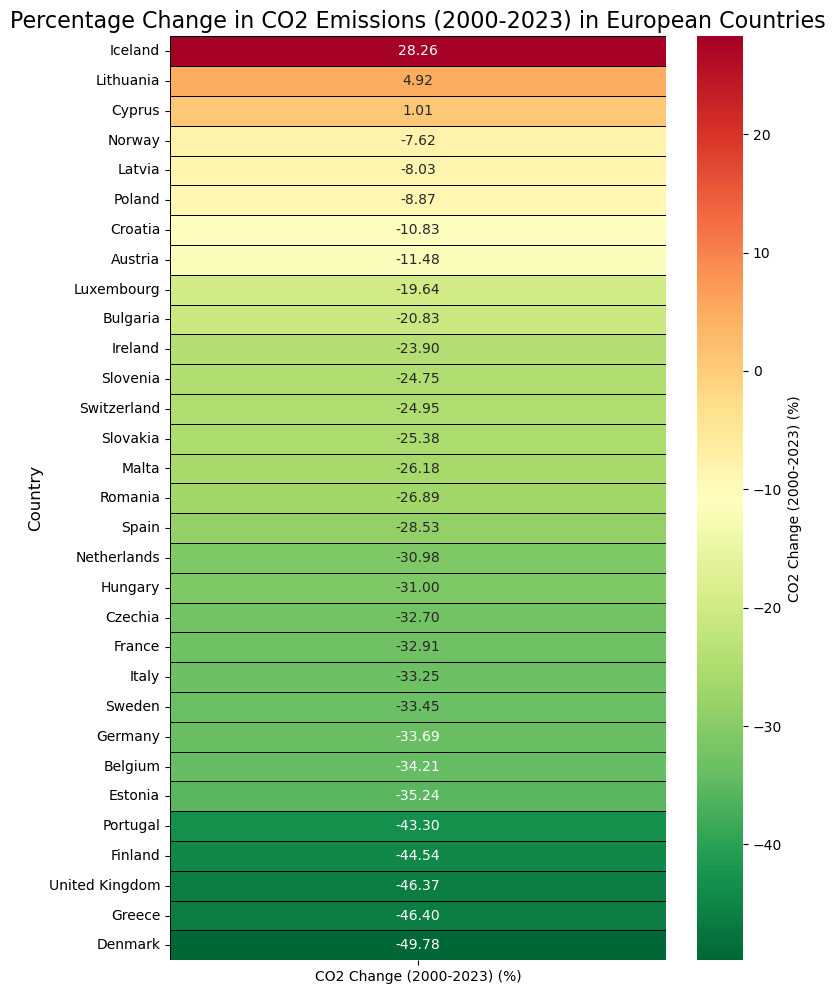

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
owid_co2_data_df = pd.read_csv('owid-co2-data.csv')

# List of European countries (can be adjusted)
european_countries = [
    'Austria', 'Belgium', 'Bulgaria', 'Croatia', 'Cyprus', 'Czechia', 'Denmark',
    'Estonia', 'Finland', 'France', 'Germany', 'Greece', 'Hungary', 'Ireland',
    'Italy', 'Latvia', 'Lithuania', 'Luxembourg', 'Malta', 'Netherlands',
    'Poland', 'Portugal', 'Romania', 'Slovakia', 'Slovenia', 'Spain', 'Sweden',
    'United Kingdom', 'Norway', 'Switzerland', 'Iceland'
]

# Filter for European countries and relevant years
start_year_v8 = 2000
end_year_v8 = owid_co2_data_df['year'].max() # Get the latest year available in the dataset

df_co2_change = owid_co2_data_df[
    (owid_co2_data_df['country'].isin(european_countries)) &
    ((owid_co2_data_df['year'] == start_year_v8) | (owid_co2_data_df['year'] == end_year_v8))
].copy()

# Pivot the table to get start and end year CO2 emissions side by side for each country
df_co2_pivot = df_co2_change.pivot_table(index='country', columns='year', values='co2').reset_index()
df_co2_pivot.columns.name = None # Remove the columns name attribute

# Calculate percentage change
df_co2_pivot['CO2 Change (%)'] = ((df_co2_pivot[end_year_v8] - df_co2_pivot[start_year_v8]) / df_co2_pivot[start_year_v8]) * 100

# Drop rows with NaN values in 'CO2 Change (%)' (countries for which data is not complete for both years)
df_co2_change_final = df_co2_pivot.dropna(subset=['CO2 Change (%)']).sort_values(by='CO2 Change (%)', ascending=False)

# Prepare data for heatmap: reshape to a single column for the value to be mapped to color
# For a single column, a bar chart or a "strip" heatmap is typically used.
# To make it a heatmap, we can create a dummy column.
df_heatmap_data = df_co2_change_final[['country', 'CO2 Change (%)']].copy()
df_heatmap_data['Metric'] = f'CO2 Change ({start_year_v8}-{end_year_v8}) (%)'

# Create a pivot table suitable for heatmap (country vs. metric)
heatmap_pivot = df_heatmap_data.pivot_table(index='country', columns='Metric', values='CO2 Change (%)')

# Sort the index of the pivot table to match the sorted order from df_co2_change_final
heatmap_pivot = heatmap_pivot.reindex(df_co2_change_final['country'])


plt.figure(figsize=(8, 12))
sns.heatmap(heatmap_pivot,
            annot=True,
            cmap='RdYlGn_r', # Red-Yellow-Green, reversed for green (good/reduction) to red (bad/increase)
            fmt=".2f",
            linewidths=.5,
            linecolor='black',
            cbar_kws={'label': f'CO2 Change ({start_year_v8}-{end_year_v8}) (%)'})

plt.title(f'Percentage Change in CO2 Emissions ({start_year_v8}-{end_year_v8}) in European Countries', fontsize=16)
plt.ylabel('Country', fontsize=12)
plt.yticks(rotation=0) # Keep country names horizontal
plt.xlabel('') # Remove x-label as it's a dummy column
plt.show()

Climate scientists consistently warn of limited time to act effectively, with global CO2 emissions needing drastic cuts by 2030 to limit warming to 1.5°C (IPCC, 2022). The ongoing presence of high total emissions in key European economies, as shown by the **Total CO2 emissions in Europe (2023 data)** map, underscores the immediate imperative for these nations to accelerate their transition.


In conclusion, Europe's energy transition is a complex balancing act between climate imperative and economic reality. While some countries are leading the way in renewable adoption and emission reductions, the continent still faces significant challenges in decarbonizing major economies, managing price volatility, and addressing the legacy of fossil fuel use. The insights from these eight graphs collectively paint a detailed picture of progress, persistent hurdles, and the immense, urgent task ahead for Europe to secure a clean and reliable energy future.